# **RFscorer チュートリアル 応用編 (日本語): 日付をもたない時系列データへの対応**

このノートブックでは、`time_col`（時系列カラム）が**日付文字列ではなく整数値**の場合に `rfscorer` を利用する方法を説明します。

具体的には次のワークフローを通じて学びます。

1. 日付文字列を**連番整数（0, 1, 2, …）にマッピング**（このチュートリアル固有のポイント）
2. 整数値のまま `split_by_date()` でデータを分割
3. `fit()` でモデルを構築・可視化
4. 整数値の基準時点を指定して `transform()` で推薦スコアを計算

ワークフロー自体は実践編（`tutorial_practical_ja.ipynb`）と同一であり、ステップ 1 の整数変換が追加されるだけです。

**このチュートリアルが想定するシーン**
- カレンダー概念を持たない時系列データ
- 時系列が日付ではなく「セッション番号」「期番号」「週番号」などの連番で管理されているデータ
- 日付フォーマットが標準でなくパースが煩雑な場合に、前処理で整数化して扱いたいケース

なお、Google Colab で利用する場合、次の準備が必要になります。
- `rfscorer`のインストール
```python
!pip install rfscorer
```
- Googleドライブのマウント（ファイルの入出力をする場合）
```python
from google.colab import drive
drive.mount("/content/drive")
```

---
## **データ取得と前処理**
GitHub上の公開データセットをURL経由でデータフレームとして直接読み込み、次の2段階でデータを分割します。

- **時系列分割**: 基準時点で区切り、過去を訓練・直近を評価に使う（運用＝過去データで未来を予測する状況を再現）
- **期間分割**: 各データを観測データと正解データに分ける


In [1]:
import pandas as pd

from rfscorer import RecencyFrequencyScorer, split_by_date

In [2]:
# `access_log.csv` は ohmsha/PyOptBook (MIT License)
# https://github.com/ohmsha/PyOptBook/tree/main/7.recommendation
url = "https://raw.githubusercontent.com/ohmsha/PyOptBook/main/7.recommendation/access_log.csv"
df = pd.read_csv(url)
# 一時的に datetime としてロードする（次のセルで整数値の session カラムに変換する）
df.columns = ["user", "item", "datetime"]

print("record num:", len(df))
print("user num:", len(df.user.unique()))
print("item num:", len(df.item.unique()))
print("datetime num:", len(sorted(df.datetime.unique())))
print("datetime:", sorted(df.datetime.unique()))
df.head()

record num: 325908
user num: 31443
item num: 87611
datetime num: 8
datetime: ['2015-07-01', '2015-07-02', '2015-07-03', '2015-07-04', '2015-07-05', '2015-07-06', '2015-07-07', '2015-07-08']


,user,item,datetime
0,4,205587,2015-07-04
1,4,748683,2015-07-04
2,4,790055,2015-07-04
3,4,790055,2015-07-04
4,4,764638,2015-07-04


In [3]:
# ─── このチュートリアルのポイント ─────────────────────────────────
# 日付文字列を連番整数（0, 1, 2, …）にマッピングし、session カラムとして追加する
# 以降の split_by_date / fit / transform はすべて session（整数値）で動作し、
# 呼び出し方は日付文字列の場合と変わらない
# ──────────────────────────────────────────────────────────────────
datetime2int = {d: i for i, d in enumerate(sorted(df.datetime.unique()))}
print(datetime2int)

df["session"] = df["datetime"].map(datetime2int)
df = df.drop(columns=["datetime"])
df.head()

{'2015-07-01': 0, '2015-07-02': 1, '2015-07-03': 2, '2015-07-04': 3, '2015-07-05': 4, '2015-07-06': 5, '2015-07-07': 6, '2015-07-08': 7}


,user,item,session
0,4,205587,3
1,4,748683,3
2,4,790055,3
3,4,790055,3
4,4,764638,3


In [4]:
# df_train: 学習時点で利用可能なデータ（session <= target_session=6 まで）
# df_test : 評価用（予測対象時点 gt_session=7 を含む）
target_session = 6  # '2015-07-07' に対応
gt_session = 7  # '2015-07-08' に対応
df_train = df[df.session <= target_session]
df_test = df[df.session <= gt_session]

print("train record num:", len(df_train), "/ user num:", len(df_train.user.unique()))
print("test  record num: ", len(df_test), "/ user num: ", len(df_test.user.unique()))

train record num: 285975 / user num: 28605
test  record num:  325908 / user num:  31443


In [5]:
# split_by_date() は整数値の time_col でも日付文字列の場合と同じ呼び出し方で動作する
# 観測データ（基準時点以前の 6 ステップ分）: 最新度・頻度を算出する期間
# 正解データ（基準時点翌ステップの 1 ステップ分）: 対象イベントの発生を記録する期間
fit_session = 5  # '2015-07-06' に対応
df_train_obs, df_train_gt = split_by_date(
    df_train, fit_session, observation_days=6, gt_days=1, time_col="session"
)
df_test_obs, df_test_gt = split_by_date(
    df_test, target_session, observation_days=6, gt_days=1, time_col="session"
)

print("--- train ---")
print("obs/session num:", len(sorted(df_train_obs.session.unique())))
print(sorted(df_train_obs.session.unique()))
print("gt/session num:", len(sorted(df_train_gt.session.unique())))
print(sorted(df_train_gt.session.unique()))

print("--- test ---")
print("obs/session num:", len(sorted(df_test_obs.session.unique())))
print(sorted(df_test_obs.session.unique()))
print("gt/session num:", len(sorted(df_test_gt.session.unique())))
print(sorted(df_test_gt.session.unique()))

--- train ---
obs/session num: 6
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
gt/session num: 1
[np.int64(6)]
--- test ---
obs/session num: 6
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
gt/session num: 1
[np.int64(7)]


---
## **モデル構築と可視化**

訓練データを使って経験的商品選択確率を推定し（`fit`）、4 種の最適化モデルを構築します。

| モデル | 種別 | 制約 |
|--------|------|------|
| `emp` | 経験的（2D） | なし |
| `er` / `ef` | 経験的（1D） | なし |
| `mono` | 最適化（2D） | 単調性のみ |
| `mrc` | 最適化（2D） | 単調性 + Recency 凸性 |
| `mfc` | 最適化（2D） | 単調性 + Frequency 凹性 |
| `mcc` | 最適化（2D） | 単調性 + Recency 凸性 + Frequency 凹性 |


In [6]:
# time_col="session" を指定（デフォルトの "datetime" とは異なるため引数が必要）
scorer = RecencyFrequencyScorer(time_col="session")

In [7]:
# === fit ===
# fit_session    : 2015-07-06: 5
# target_session : 2015-07-07: 6
# gt_session     : 2015-07-08: 7
#                         f  t  g
#                         ^  ^  ^
# int time 0  1  2  3  4  5  6  7
# test        *  *  *  *  *  *  @
# train    *  *  *  *  *  *  @
# *: 観測（observation_days=6）,  @: 正解（gt_days=1）
scorer.fit(df_train_obs, df_train_gt, ref=fit_session, recency_limit=6, frequency_limit=15)

scorer.show()  # データ統計・相関係数・経験的商品選択確率テーブルを表示

=== RecencyFrequencyScorer ===

── Data ──────────────────────────────────────────────
  dataset          : obs 252045 rows,  gt 33930 events  (users: 26030,  items: 74811)
  observation      : 0 → 5
  user×item pairs  : 180840 → 180752  (before → after applying limits)
  target events    : 1597 → 1585  (before → after applying limits)

── Model ─────────────────────────────────────────────
  recency_mode     : day
  recency_limit    : 6
  frequency_limit  : 15

── Correlation ───────────────────────────────────────
  [expected: recency ρ < 0  (more recent → higher prob),
             frequency ρ > 0  (more frequent → higher prob)]
  recency  ρ       : -1.0000  (p=0.0000,  n=6,  weighted ρ: -1.0000)
  frequency ρ      :  0.6500  (p=0.0087,  n=15,  weighted ρ:  0.9713)

  Slice ρ by r  [corr(f, P(r,f)),  expected > 0]
    r= 1:   0.9280
    r= 2:   0.9854
    r= 3:   0.7712
    r= 4:   0.9303
    r= 5:   0.6182
    r= 6:   0.4109
  Slice ρ by f  [corr(r, P(r,f)),  expected < 0]
    f= 1

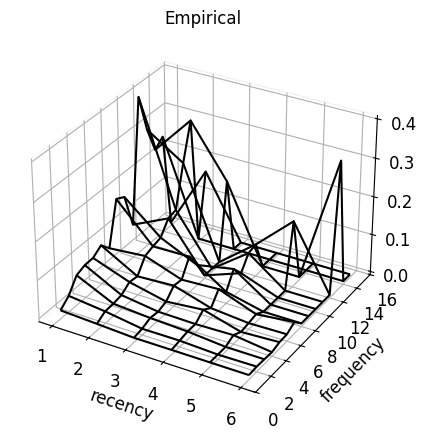

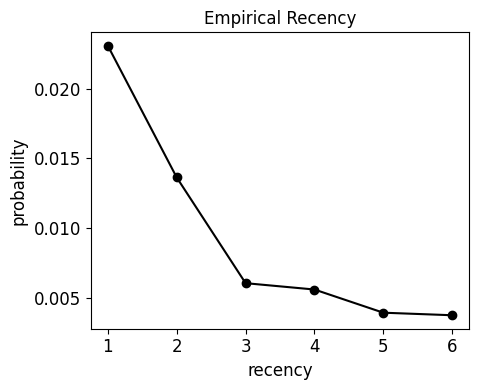

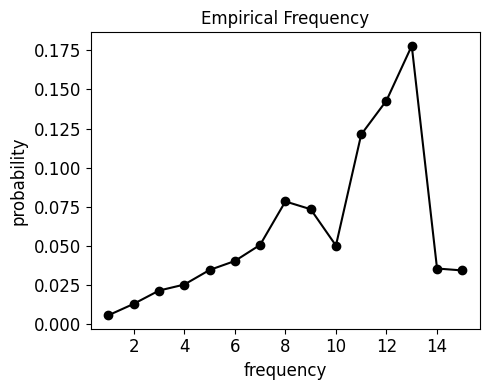

In [8]:
# emp: 経験的商品選択確率（2次元の生テーブル。標本ノイズを含む）
# er / ef: 最新度・頻度それぞれの1次元経験的商品選択確率
fig_emp = scorer.plot_probability_surface(kind="emp")
fig_er = scorer.plot_marginal_probability(kind="er")
fig_ef = scorer.plot_marginal_probability(kind="ef")

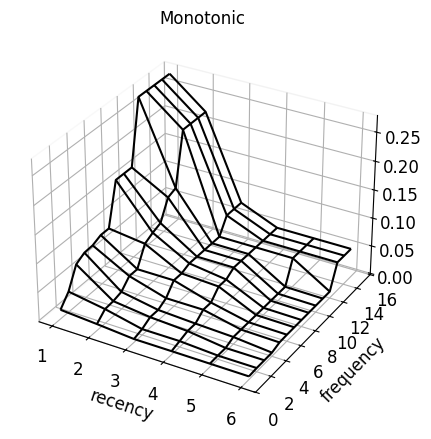

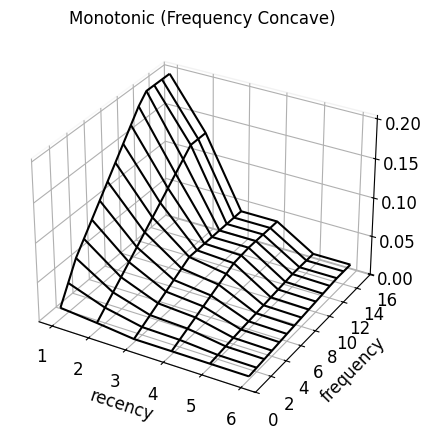

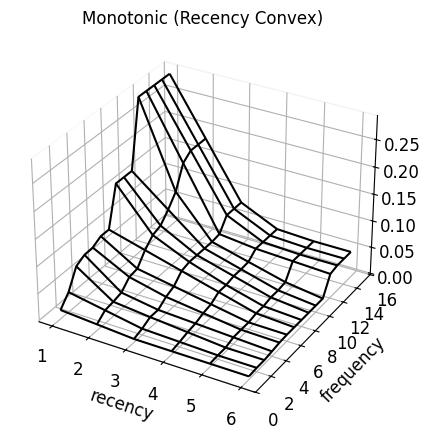

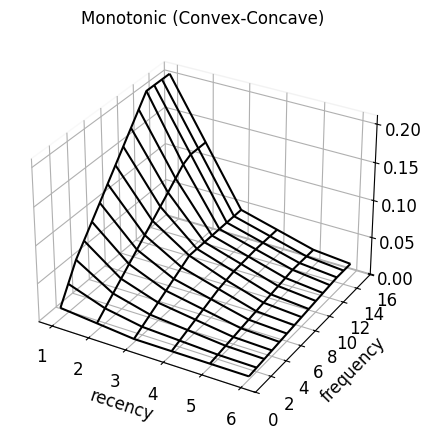

In [9]:
# 2次元の最適化モデル: mono(単調性のみ) / mrc(+Recency凸性) / mfc(+Frequency凹性) / mcc(+両方)
scorer.optimize(kind="mono")
scorer.optimize(kind="mrc")
scorer.optimize(kind="mfc")
scorer.optimize(kind="mcc")

fig_mono = scorer.plot_probability_surface(kind="mono")
fig_mfc = scorer.plot_probability_surface(kind="mfc")
fig_mrc = scorer.plot_probability_surface(kind="mrc")
fig_mcc = scorer.plot_probability_surface(kind="mcc")

---
## **推薦スコアの計算**

`transform()` の `ref` にも整数値をそのまま渡せます。
呼び出し方は日付文字列を使う場合と変わりません。

In [10]:
# ref=target_session: 整数値の基準時点を基準に最新度を計算
df_rec = scorer.transform(df_test_obs, target_session, kind="mcc")
df_rec.head()

,user,item,recency,frequency,probability,order
71,100,311746,6,1,0.003398,1
72,100,185046,6,1,0.003398,2
73,100,1002465,6,1,0.003398,3
40705,100003,675829,4,1,0.003634,1
40706,100003,979166,4,1,0.003634,2
